# Análise dos dados para responder as questões 

In [1]:

# Imports e configuração 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


# Estilo visual padronizado
paleta   = ["#4A90D9", "#E8A838", "#E05C5C", "#5DBE7E", "#9B59B6"]
paleta_status = {
    "entregue":    "#5DBE7E",
    "cancelado":   "#E05C5C",
    "devolvido":   "#E8A838",
    "em_transito": "#4A90D9",
}

sns.set_theme(style="whitegrid", palette=paleta)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize":  14,
    "axes.labelsize":  12,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "font.family": "sans-serif",
})
pd.set_option("display.float_format", "{:,.2f}".format)

# Caminhos
caminho = Path("outputs")

# Carregamento das bases tratadas
df_pedidos  = pd.read_csv(caminho / "pedidos_limpo.csv",        parse_dates=["data_pedido"])
df_clientes = pd.read_csv(caminho / "clientes_limpo.csv",       parse_dates=["data_cadastro"])
df_produtos = pd.read_csv(caminho / "produtos_limpo.csv")
df_itens    = pd.read_csv(caminho / "itens_pedido_limpo.csv")
df_tickets  = pd.read_csv(caminho / "tickets_suporte_limpo.csv",parse_dates=["data_abertura","data_resolucao"])

# print("Bases carregadas com sucesso!")
# for nome, df in [("pedidos", df_pedidos), ("clientes", df_clientes), ("produtos", df_produtos), ("itens_pedido", df_itens),("tickets", df_tickets)]:
    #print(f" {nome:<15} → {df.shape[0]:>6,} linhas")

# Pergunta 1: Qual o volume de pedidos por status? Calcule a distribuição percentual e apresente os resultados em uma tabela. Inclua uma visualização gráfica (ex: gráfico de barras ou pizza).

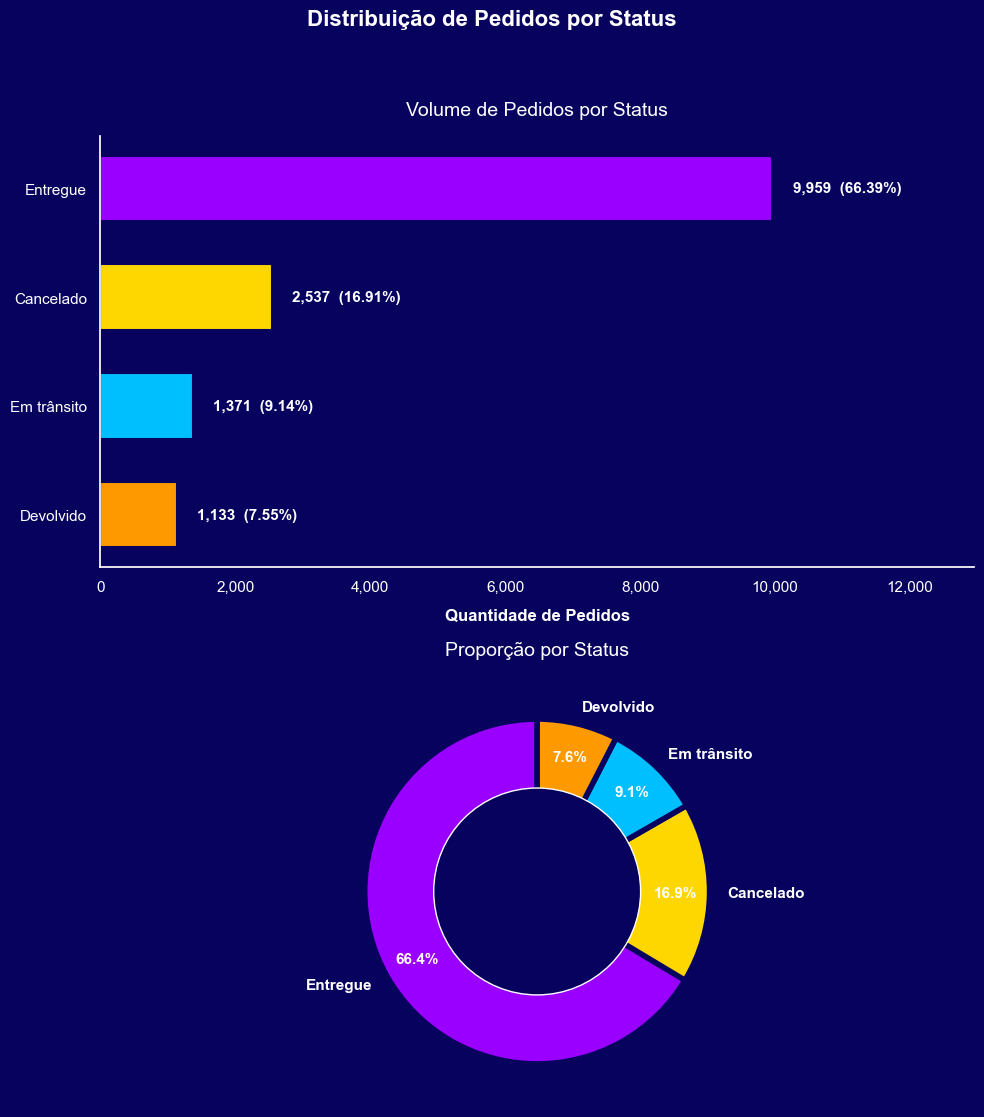

In [2]:
# Fomatação dos dados
dist_status = (
    df_pedidos["status"]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "qtd_pedidos"})
)
dist_status["percentual"] = (dist_status["qtd_pedidos"] / dist_status["qtd_pedidos"].sum() * 100).round(2)
dist_status["percentual_fmt"] = dist_status["percentual"].apply(lambda x: f"{x:.2f}%")

dist_status["status_formatado"] = dist_status["status"].replace({"em_transito": "Em trânsito"}).str.capitalize()

# Cores padronizadas para todos os gráficos e tabelas
cor_fundo = "#06025e"         
cor_principal = "#9900ff"     
cor_amarelo = "#FFD700"      
cor_laranja = "#FF9900"      
cor_azulclaro = "#00BFFF"    
cor_letra = "#FFFFFF"         

paleta_status = {
    "Entregue": cor_principal,
    "Cancelado": cor_amarelo, 
    "Devolvido": cor_laranja,
    "Em trânsito": cor_azulclaro
}

plt.rcParams.update({
    "figure.facecolor": cor_fundo,
    "axes.facecolor": cor_fundo,
    "axes.edgecolor": cor_letra,
    "axes.labelcolor": cor_letra,
    "xtick.color": cor_letra,
    "ytick.color": cor_letra,
    "text.color": cor_letra,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False 
})


# Plotagem do gráfico
fig, axes = plt.subplots(2, 1, figsize=(10, 12)) 


fig.suptitle("Distribuição de Pedidos por Status",
             fontsize=16, fontweight="bold", color=cor_letra, y=0.96)

ordem = dist_status["status_formatado"].tolist()
cores = [paleta_status[s] for s in ordem]


ax1 = axes[0]
bars = ax1.barh(
    dist_status["status_formatado"], 
    dist_status["qtd_pedidos"],
    color=cores, edgecolor=cor_fundo, height=0.6, linewidth=1.5
)
ax1.set_xlabel("Quantidade de Pedidos", fontweight="bold", labelpad=10)
ax1.set_title("Volume de Pedidos por Status", fontsize=14, pad=15)
ax1.invert_yaxis() 

for bar, (_, row) in zip(bars, dist_status.iterrows()):
    largura = bar.get_width()
    ax1.text(
        largura + 300, 
        bar.get_y() + bar.get_height() / 2,
        f"{row['qtd_pedidos']:,}  ({row['percentual_fmt']})",
        va="center", ha="left", fontsize=11, color=cor_letra, fontweight="bold"
    )

ax1.set_xlim(0, dist_status["qtd_pedidos"].max() * 1.3)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Gráfico de rosca
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    dist_status["qtd_pedidos"],
    labels=dist_status["status_formatado"],
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    pctdistance=0.80,
    textprops={'color': cor_letra, 'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={"edgecolor": cor_fundo, "linewidth": 4} 
)

centro_rosca = plt.Circle((0,0), 0.60, fc=cor_fundo)
ax2.add_artist(centro_rosca)

ax2.set_title("Proporção por Status", fontsize=14, pad=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig(
    caminho / "distribuicao_pedidos_status.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()

# Pergunta 2: Quais são os 10 produtos mais vendidos (por quantidade total de itens vendidos)? Apresente também a receita gerada por cada um deles.

                           10 PRODUTOS MAIS VENDIDOS NA EMPRESA:     


,Produto,Categoria,Unidades Vendidas,Receita Total (R$),Nº de Pedidos
1,Acessórios 43,Moda,673,"R$ 787,496.54",213
2,Tênis Esportivo 78,Esporte & Lazer,669,"R$ 1,895,127.99",225
3,Tênis Esportivo 75,Esporte & Lazer,663,"R$ 1,117,968.89",217
4,Notebooks 172,Eletrônicos,653,"R$ 1,576,158.26",208
5,Roupas Íntimas 48,Moda,651,"R$ 1,782,322.00",213
6,Vitaminas 111,Beleza & Saúde,649,"R$ 1,503,829.56",205
7,Cosméticos 92,Beleza & Saúde,642,"R$ 1,131,307.74",220
8,Chás 118,Alimentos & Bebidas,637,"R$ 1,647,425.12",202
9,Suplementos 194,Beleza & Saúde,635,"R$ 503,029.46",205
10,Quadros 65,Casa & Decoração,633,"R$ 1,472,981.87",204


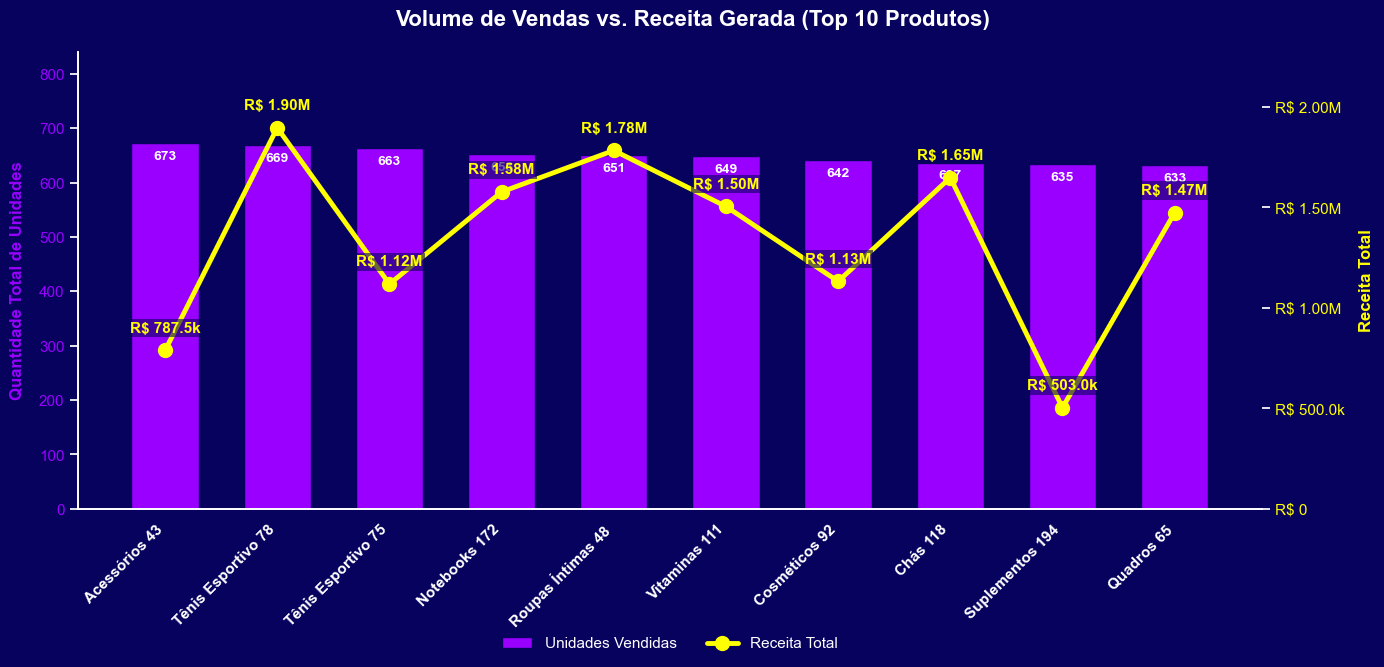

In [3]:
# Agregação dos dados
agg_produtos = (
    df_itens
    .groupby("produto_id")
    .agg(
        total_unidades=("quantidade", "sum"),
        receita_total=("valor_liquido_item", "sum"),
        num_pedidos=("pedido_id", "nunique"),
    )
    .reset_index()
)

agg_produtos = agg_produtos.merge(
    df_produtos[["id", "nome", "categoria", "subcategoria"]],
    left_on="produto_id", right_on="id"
).drop(columns="id")

top10 = (
    agg_produtos
    .sort_values("total_unidades", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1  

# Nomes formatados para os gráficos 
nomes_grafico = top10["nome"].apply(lambda x: x[:30] + "..." if len(x) > 30 else x)


# Construção da tabela
tabela_top10 = top10[["nome", "categoria", "total_unidades", "receita_total", "num_pedidos"]].copy()
tabela_top10.columns = ["Produto", "Categoria", "Unidades Vendidas", "Receita Total (R$)", "Nº de Pedidos"]

estilos_tabela = [
    {'selector': 'th',
     'props': [('background-color', '#06025e'), 
               ('color', 'white'), 
               ('font-family', 'sans-serif'),
               ('text-align', 'center'),
               ('font-weight', 'bold')]}
]

print("                           10 PRODUTOS MAIS VENDIDOS NA EMPRESA:     ")
display(
    tabela_top10.style
    .background_gradient(subset=["Unidades Vendidas"], cmap="Purples") # Gradiente Roxo
    .background_gradient(subset=["Receita Total (R$)"], cmap="YlOrBr")  # Gradiente Amarelo/Ouro (Refatorado)
    .set_table_styles(estilos_tabela)
    .format({"Unidades Vendidas": "{:,}", "Receita Total (R$)": "R$ {:,.2f}", "Nº de Pedidos": "{:,}"})
)

# Construção do gráfico
def formatar_moeda(valor, _=None):
    if valor >= 1_000_000:
        return f"R$ {valor/1_000_000:.2f}M" # Transforma em milhões
    elif valor >= 1_000:
        return f"R$ {valor/1_000:.1f}k"      # Mantém em Milhares
    else:
        return f"R$ {valor:.0f}"

cor_amareloforte = "#FFFF00" 

fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle("Volume de Vendas vs. Receita Gerada (Top 10 Produtos)", 
             fontsize=16, fontweight="bold", color=cor_letra, y=0.98)

nomes_x = top10["nome"].apply(lambda x: x[:20] + "..." if len(x) > 20 else x)
x_indexes = np.arange(len(nomes_x))


bars = ax1.bar(x_indexes, top10["total_unidades"], 
               color=cor_principal, edgecolor=cor_fundo, width=0.6, label="Unidades Vendidas")

ax1.set_ylabel("Quantidade Total de Unidades", fontweight='bold', labelpad=10, color=cor_principal)
ax1.tick_params(axis='y', labelcolor=cor_principal)
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(nomes_x, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax1.set_ylim(0, top10["total_unidades"].max() * 1.25) 

for bar in bars:
    altura = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, altura - (top10["total_unidades"].max() * 0.02),
             f"{int(altura):,}", 
             ha='center', va='top', fontsize=10, color=cor_letra, fontweight='bold')

ax2 = ax1.twinx() 

linha = ax2.plot(x_indexes, top10["receita_total"], 
                 color=cor_amareloforte, marker='o', markersize=10, linewidth=3.5, 
                 linestyle='-', label="Receita Total")

ax2.set_ylabel("Receita Total", fontweight='bold', labelpad=10, color=cor_amareloforte)
ax2.tick_params(axis='y', labelcolor=cor_amareloforte)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(formatar_moeda))
ax2.set_ylim(0, top10["receita_total"].max() * 1.2) 

for i, txt in enumerate(top10["receita_total"]):
    texto_formatado = formatar_moeda(txt) 
    ax2.text(x_indexes[i], txt + (top10["receita_total"].max() * 0.04), 
             texto_formatado, 
             ha='center', va='bottom', fontsize=11, color=cor_amareloforte, fontweight='bold',
             bbox=dict(facecolor=cor_fundo, edgecolor='none', alpha=0.6, pad=1.5))

# Acabamentos do gráfico
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.grid(False) 
ax2.grid(False)

linhas_labels1, labels1 = ax1.get_legend_handles_labels()
linhas_labels2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(linhas_labels1 + linhas_labels2, labels1 + labels2, 
           loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, 
           frameon=False, labelcolor=cor_letra, fontsize=11)

plt.tight_layout()
plt.savefig(
    caminho / "volumeVendas_vs_receitaGerada.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()
plt.show()

# Análise:

Ao cruzar a quantidade de produtos vendidos com a receita gerada, percebe-se que nem todos os produtos com mais unidades vendidas são os com maiores receitas e, caso a quantidade de tickets de suporte for alta para esses produtos, temos implicações relevantes para a empresa.
Uma análise relevante seria verificar qual tipo de produto resulta em mais tickets de suporte. Dessa forma, conseguiríamos verificar se os produtos com mais unidades vendidas, mais receita total ou nenhuma dessas categorias são as que estão causando os altos cancelamentos apresentados. 

# Pergunta 3: Qual o ticket médio de pedidos por segmento de cliente (B2C vs B2B)? Existe diferença estatisticamente relevante?

   RESUMO: 
Ticket Médio B2C: R$ 1,312.71
Ticket Médio B2B: R$ 7,796.41

Teste de hipóteses (Teste T de Welch em escala logarítmica):
Estatística T : -115.9570
P-Valor       : 0.0000e+00
A diferença é significativa!


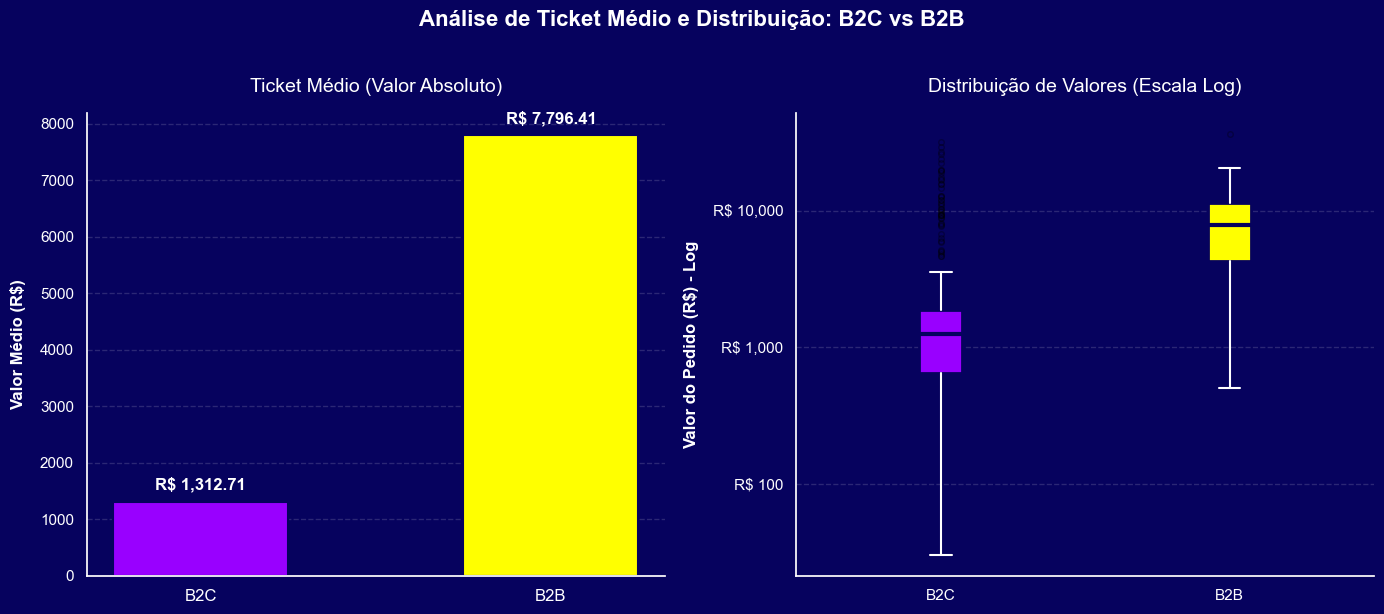

In [4]:
# Decidi transformar os valores em uma escala logarítmica (pois temos vários outliers) para implementar
# o teste T de Welch

# Merge Pedidos + Clientes, trazendo o segmento da tabela de clientes para a tabela de pedidos
df_q3 = df_pedidos.merge(
    df_clientes[['id', 'segmento']], 
    left_on='cliente_id', 
    right_on='id', 
    how='left'
).drop(columns=['id_y'])

# Separando as duas amostras ignorando eventuais nulos
b2c_valores = df_q3[df_q3['segmento'] == 'B2C']['valor_total'].dropna()
b2b_valores = df_q3[df_q3['segmento'] == 'B2B']['valor_total'].dropna()

ticket_medio_b2c = b2c_valores.mean()
ticket_medio_b2b = b2b_valores.mean()

print("   RESUMO: ")
print(f"Ticket Médio B2C: R$ {ticket_medio_b2c:,.2f}")
print(f"Ticket Médio B2B: R$ {ticket_medio_b2b:,.2f}\n")


# Aplicamos o log para normalizar a assimetria dos dados
log_b2c = np.log1p(b2c_valores)
log_b2b = np.log1p(b2b_valores)

# equal_var=False aciona o Teste T de Welch 
t_stat, p_valor = stats.ttest_ind(log_b2c, log_b2b, equal_var=False)

print("Teste de hipóteses (Teste T de Welch em escala logarítmica):")
print(f"Estatística T : {t_stat:.4f}")
print(f"P-Valor       : {p_valor:.4e}")

if p_valor < 0.05:
    print("A diferença é significativa!")
else:
    print("Não há diferença significativa entre os dois casos")


# Gráfico de barras e box plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Análise de Ticket Médio e Distribuição: B2C vs B2B", 
             fontsize=16, fontweight="bold", color=cor_letra, y=1.02)

segmentos = ['B2C', 'B2B']
medias = [ticket_medio_b2c, ticket_medio_b2b]
cores = [cor_principal, cor_amareloforte]

bars = ax1.bar(segmentos, medias, color=cores, edgecolor=cor_fundo, width=0.5, linewidth=1.5)
ax1.set_title("Ticket Médio (Valor Absoluto)", fontsize=14, pad=15)
ax1.set_ylabel("Valor Médio (R$)", fontweight='bold', labelpad=10)
ax1.tick_params(axis='x', labelsize=12)

for bar in bars:
    altura = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, altura + (max(medias) * 0.02),
             f"R$ {altura:,.2f}", 
             ha='center', va='bottom', fontsize=12, color=cor_letra, fontweight='bold')

# O box plot foi usado para visualizar outliers
bp = ax2.boxplot([b2c_valores, b2b_valores], 
                 tick_labels=segmentos, 
                 patch_artist=True,
                 boxprops=dict(color=cor_fundo, linewidth=2),
                 capprops=dict(color=cor_letra, linewidth=1.5),
                 whiskerprops=dict(color=cor_letra, linewidth=1.5),
                 flierprops=dict(marker='o', color=cor_letra, alpha=0.3, markersize=4),
                 medianprops=dict(color=cor_fundo, linewidth=3)) # Mediana vazada para contraste

# Colorindo as caixas do boxplot
bp['boxes'][0].set_facecolor(cor_principal)
bp['boxes'][1].set_facecolor(cor_amareloforte)


ax2.set_yscale('log')
ax2.set_title("Distribuição de Valores (Escala Log)", fontsize=14, pad=15)
ax2.set_ylabel("Valor do Pedido (R$) - Log", fontweight='bold', labelpad=10)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"R$ {y:,.0f}"))

# Acabamentos
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Ligando a grade sutil no eixo Y para facilitar a leitura da altura
    ax.grid(axis='y', color=cor_letra, linestyle='--', alpha=0.15) 

plt.tight_layout()
plt.savefig(
    caminho / "analise_ticketMedio_distribuicao.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()

# Análise 

Ao tentar formular um teste de hipóteses para verificar se existe diferença estatisticamente relevante entre os dois segmentos, percebi que o volume de pedidos baratos é muito maior do que o volume de pedidos caros, o que impossibilitou usar testes tradicionais (que pressupõem uma distribuição normal para os dados). Desse modo, apliquei uma transformação logarítmica com teste T de Welch.
O p-valor resultante foi menor do que 0.05, o que permitiu rejeitar H0, evidenciando que a diferença de ticket médio entre B2B e B2C é significativa e estrutural. 
Com o ticket médio do B2B se revelando drasticamente superior ao do B2C, é possível inferir que os clientes B2B são os que mais trazem rentabilidade para a empresa. 
Se a alta taxa de cancelamentos e devoluções estiver atingindo a base B2B, o faturamento da empresa tende a cair drasticamente. 


# Pergunta 4: Analise a evolução mensal do volume de pedidos ao longo de 2023 e 2024. Há sazonalidade? Identifique picos e quedas e formule uma hipótese para cada padrão encontrado.

Performance de vendas em cada mês:


,Pedidos 2023,Pedidos 2024,Variação YoY (%)
Jan,525,542,3.238095
Fev,492,499,1.422764
Mar,613,551,-10.114192
Abr,564,558,-1.063830
Mai,579,608,5.008636
Jun,531,498,-6.214689
Jul,542,588,8.487085
Ago,584,599,2.568493
Set,527,521,-1.138520
Out,554,545,-1.624549


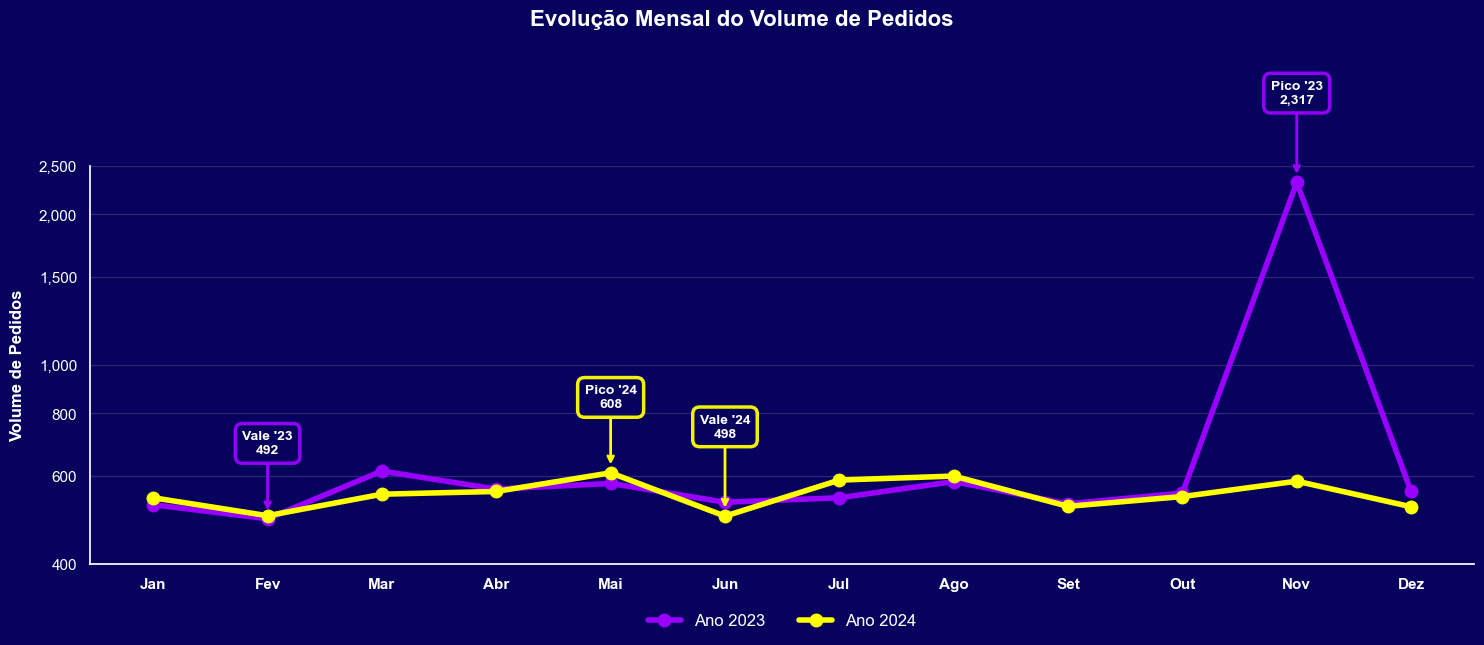

In [5]:
# Preparação dos dados
df_pedidos["ano"] = df_pedidos["data_pedido"].dt.year
df_pedidos["mes"] = df_pedidos["data_pedido"].dt.month

evolucao_mensal = (
    df_pedidos
    .groupby(["ano", "mes"])
    .agg(
        qtd_pedidos=("id", "count"),
        receita_total=("valor_total", "sum"),
    )
    .reset_index()
)

meses_pt = {1:"Jan", 2:"Fev", 3:"Mar", 4:"Abr", 5:"Mai", 6:"Jun",
            7:"Jul", 8:"Ago", 9:"Set", 10:"Out", 11:"Nov", 12:"Dez"}
evolucao_mensal["mes_nome"] = evolucao_mensal["mes"].map(meses_pt)

df_2023 = evolucao_mensal[evolucao_mensal["ano"] == 2023]
df_2024 = evolucao_mensal[evolucao_mensal["ano"] == 2024]

def get_pico_vale(df_ano):
    pico = df_ano.loc[df_ano["qtd_pedidos"].idxmax()]
    vale = df_ano.loc[df_ano["qtd_pedidos"].idxmin()]
    return pico, vale

pico_23, vale_23 = get_pico_vale(df_2023)
pico_24, vale_24 = get_pico_vale(df_2024)

# Tabela para comparação 
pivot_mensal = evolucao_mensal.pivot_table(
    index="mes_nome", columns="ano", values="qtd_pedidos"
).reindex(list(meses_pt.values()))


pivot_mensal.index.name = None

pivot_mensal.columns = ["Pedidos 2023", "Pedidos 2024"]
pivot_mensal["Variação YoY (%)"] = (
    (pivot_mensal["Pedidos 2024"] - pivot_mensal["Pedidos 2023"])
    / pivot_mensal["Pedidos 2023"] * 100
)
estilos_tabela = [
    {'selector': 'thead th', 
     'props': [('background-color', '#06025e'), 
               ('color', 'white'), 
               ('text-align', 'center'),
               ('padding', '6px 15px')]}, 
    {'selector': 'tbody th', 
     'props': [('text-align', 'center')]} 
]

print("Performance de vendas em cada mês:")
display(
    pivot_mensal.style
    .background_gradient(subset=["Pedidos 2023"], cmap="Purples")
    .background_gradient(subset=["Pedidos 2024"], cmap="YlOrBr")
    .set_table_styles(estilos_tabela)
    .format({"Pedidos 2023": "{:,.0f}", "Pedidos 2024": "{:,.0f}", "Variação(%)": "{:.1f}%"})
)
# Gráfico de série temporal
cor_fundo = "#06025e"
cor_letra = "#FFFFFF"
cor_principal = "#9900ff"
cor_amareloforte = "#FFFF00"

fig, ax = plt.subplots(figsize=(15, 7), facecolor=cor_fundo)
ax.set_facecolor(cor_fundo)

fig.suptitle("Evolução Mensal do Volume de Pedidos", 
             fontsize=16, fontweight="bold", color=cor_letra, y=0.98)


ax.plot(df_2023["mes"], df_2023["qtd_pedidos"],
        marker="o", color=cor_principal, linewidth=4, markersize=9, label="Ano 2023")

ax.plot(df_2024["mes"], df_2024["qtd_pedidos"],
        marker="o", color=cor_amareloforte, linewidth=4, markersize=9, label="Ano 2024")

def anotar_sazonalidade(x, y, texto, cor_borda, offset_pixels):
    ax.annotate(texto,
                xy=(x, y), xytext=(0, offset_pixels), textcoords="offset points", 
                fontsize=10, fontweight="bold", color=cor_letra, 
                ha='center', va='bottom',
                bbox=dict(boxstyle="round,pad=0.5", fc=cor_fundo, ec=cor_borda, lw=2.5, alpha=0.95),
                arrowprops=dict(arrowstyle="->", color=cor_borda, lw=2, shrinkA=0, shrinkB=6))

anotar_sazonalidade(pico_23["mes"], pico_23["qtd_pedidos"], f"Pico '23\n{int(pico_23['qtd_pedidos']):,}", cor_principal, 55)
anotar_sazonalidade(pico_24["mes"], pico_24["qtd_pedidos"], f"Pico '24\n{int(pico_24['qtd_pedidos']):,}", cor_amareloforte, 45)
anotar_sazonalidade(vale_23["mes"], vale_23["qtd_pedidos"], f"Vale '23\n{int(vale_23['qtd_pedidos']):,}", cor_principal, 45)
anotar_sazonalidade(vale_24["mes"], vale_24["qtd_pedidos"], f"Vale '24\n{int(vale_24['qtd_pedidos']):,}", cor_amareloforte, 55)

# Escala e eixos
ax.set_yscale('log')
ticks_desejados = [400, 600, 800, 1000, 1500, 2000, 2500]
ax.set_yticks(ticks_desejados)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.minorticks_off()

ax.set_xticks(range(1, 13))
ax.set_xticklabels(list(meses_pt.values()), fontsize=11, fontweight='bold')
ax.tick_params(axis='x', colors=cor_letra) 
ax.tick_params(axis='y', colors=cor_letra) 
ax.set_ylabel("Volume de Pedidos", fontweight='bold', color=cor_letra, labelpad=10)

# Limpeza e legenda
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color(cor_letra)
ax.spines['left'].set_color(cor_letra)
ax.grid(axis='y', color=cor_letra, linestyle='-', alpha=0.15) 

ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), 
           ncol=2, frameon=False, labelcolor=cor_letra, fontsize=12)

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig(
    caminho / "evolucao_mensal_volumePedidos.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()

#  Análise de Sazonalidade 

Ao plotar a curva de evolução de pedidos, é possível observar um padrão de sazonalidade que se repete em ambos os anos:
Os meses de Fevereiro/Março representam o período de menor volume de pedidos (Pós-Festas). A hipótese é que o consumidor está descapitalizado em decorrência das festas de final de ano. 
É um momento interessante para focar em campanhas de reativação de clientes antigos e ofertas em produtos com menor ticket médio. 

Da mesma maneira, é possível questionar se as altas taxas de cancelamento se concentram no quarto período do trimestre em decorrência de alto volume de vendas (que poderia causar problemas logísticos e de atendimento). Uma análise interessante seria cruzar os meses de pico
poderiam trazer insights valiosos sobre a empresa. 

# Pergunta 5: Qual canal de aquisição de clientes apresenta a maior taxa de cancelamento de pedidos? E qual gera o maior valor médio de compra? Cruzar clientes → pedidos.

VISÃO GERAL POR CANAL



Canal de Aquisição,Total Pedidos,% Cancelado,% Devolvido,% Problema Total,Ticket Médio (R$)
paid_search,"3,965",30.74%,6.36%,37.10%,"R$ 2,623.24"
indicação,"3,658",12.38%,8.04%,20.42%,"R$ 2,585.32"
orgânico,"3,616",11.78%,8.41%,20.19%,"R$ 2,562.82"
redes_sociais,"3,761",11.67%,7.52%,19.20%,"R$ 2,687.36"



TAXA DE CANCELAMENTO POR TRIMESTRE



canal_aquisicao,indicação,orgânico,paid_search,redes_sociais
periodo,,,,
2023-1,11.5%,8.7%,27.6%,10.4%
2023-2,12.2%,12.4%,29.9%,12.4%
2023-3,14.7%,12.8%,30.8%,13.3%
2023-4,13.8%,12.9%,30.3%,10.2%
2024-1,11.8%,11.4%,32.3%,11.6%
2024-2,12.0%,13.5%,31.7%,14.0%
2024-3,10.0%,10.1%,35.0%,11.2%
2024-4,11.7%,10.9%,29.1%,11.9%


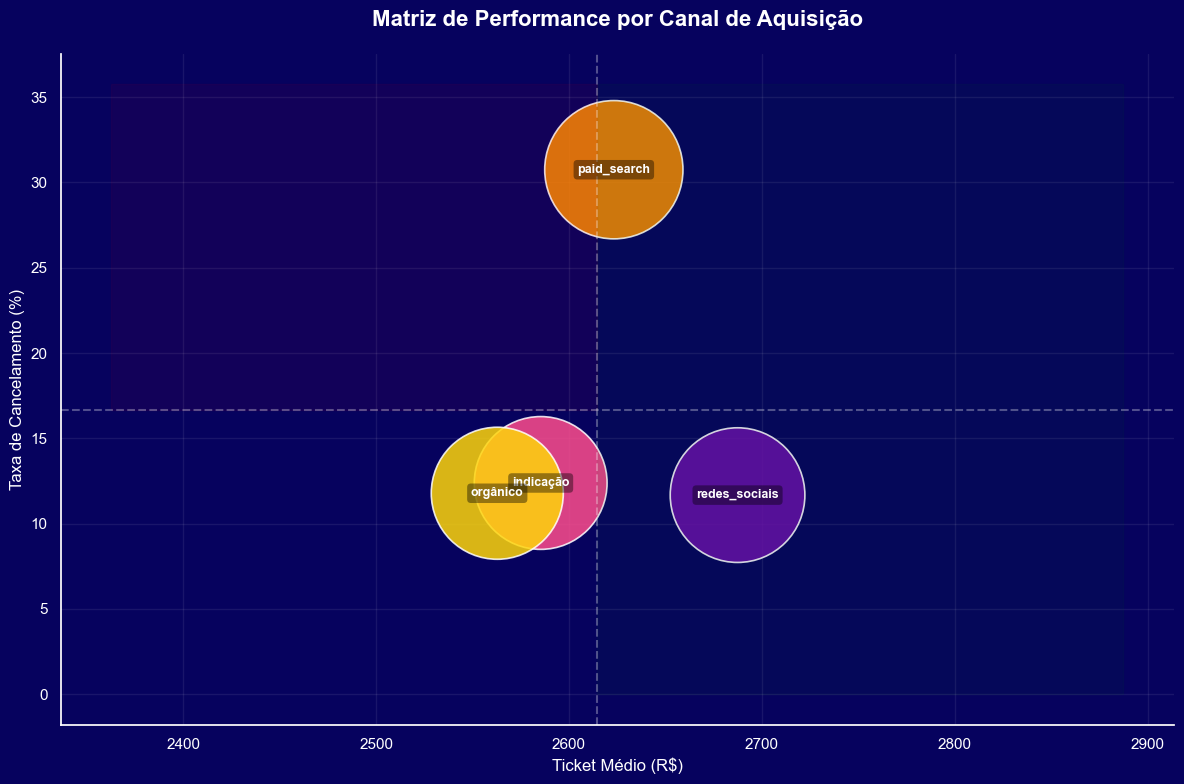

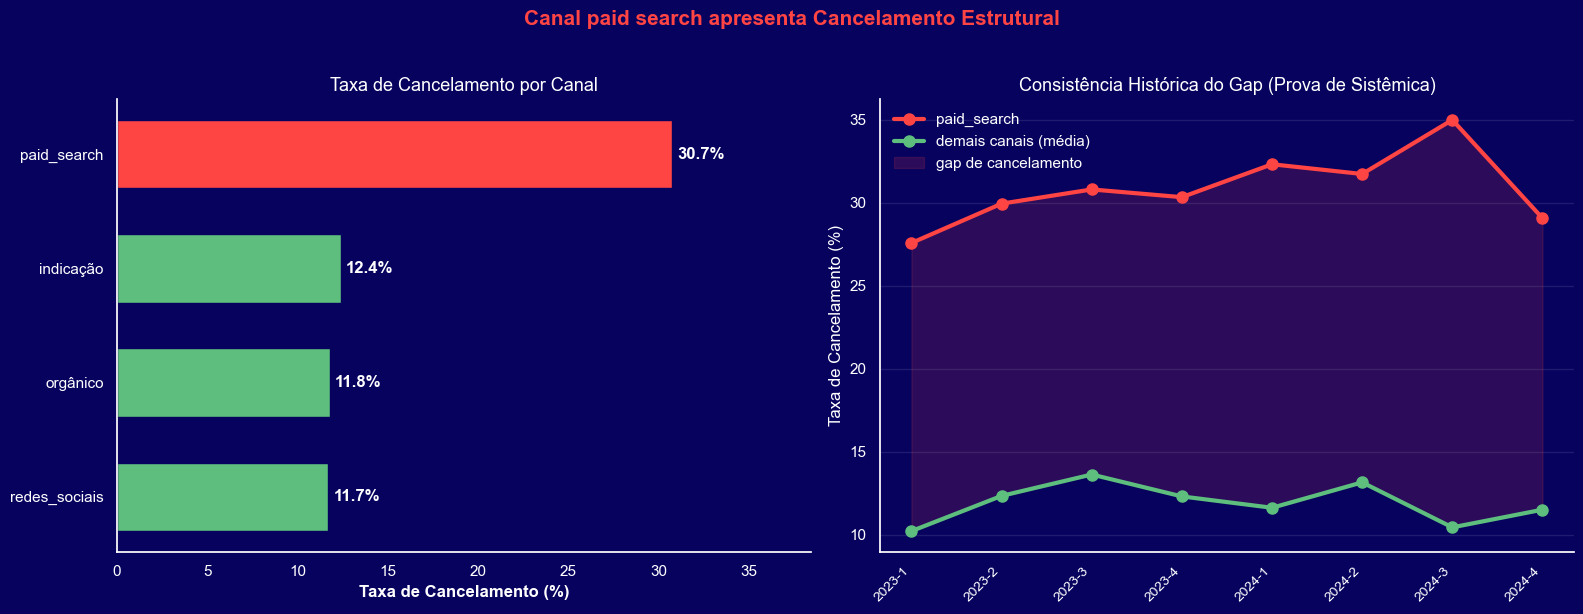

In [6]:
import unicodedata
import unicodedata
cor_fundo = "#06025e"
cor_texto = "#FFFFFF" 

# Cruzamento base de pedidos com clientes
df_pedidos_canal = df_pedidos.merge(
    df_clientes[["id", "segmento", "canal_aquisicao"]].rename(columns={"id": "cliente_id"}),
    on="cliente_id",
    how="left"
)

# Criação do período do ano para análise histórica
df_pedidos_canal['periodo'] = df_pedidos_canal['data_pedido'].dt.to_period('Q').astype(str).str.replace('Q', '-')

# Visão por Canal
analise_canal = df_pedidos_canal.groupby("canal_aquisicao").agg(
    total_pedidos=("id", "count"),
    pedidos_cancelados=("status", lambda x: (x == "cancelado").sum()),
    pedidos_devolvidos=("status", lambda x: (x == "devolvido").sum()),
    valor_medio=("valor_total", "mean")
).reset_index()

# Cálculos de taxas
analise_canal["taxa_cancelamento"] = (analise_canal["pedidos_cancelados"] / analise_canal["total_pedidos"]) * 100
analise_canal["taxa_devolucao"] = (analise_canal["pedidos_devolvidos"] / analise_canal["total_pedidos"]) * 100
analise_canal["taxa_problema"] = analise_canal["taxa_cancelamento"] + analise_canal["taxa_devolucao"]
analise_canal = analise_canal.sort_values("taxa_cancelamento", ascending=False)

# visão trimestral 
t8_hist = df_pedidos_canal.groupby(['periodo', 'canal_aquisicao']).agg(
    total_pedidos=("id", "count"),
    pedidos_cancelados=("status", lambda x: (x == "cancelado").sum())
).reset_index()
t8_hist["taxa_cancelamento"] = (t8_hist["pedidos_cancelados"] / t8_hist["total_pedidos"]) * 100

# Tabelas
print("VISÃO GERAL POR CANAL\n")
estilos_tabela = [
    {'selector': 'thead th', 'props': [('background-color', '#06025e'), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
    {'selector': 'tbody th', 'props': [('text-align', 'left'), ('padding-right', '20px')]}
]

tabela_resumo = analise_canal[["canal_aquisicao", "total_pedidos", "taxa_cancelamento", "taxa_devolucao", "taxa_problema", "valor_medio"]].copy()
tabela_resumo.columns = ["Canal de Aquisição", "Total Pedidos", "% Cancelado", "% Devolvido", "% Problema Total", "Ticket Médio (R$)"]

display(
    tabela_resumo.style
    .background_gradient(subset=["% Cancelado"], cmap="YlOrBr") 
    .background_gradient(subset=["Ticket Médio (R$)"], cmap="Purples") 
    .set_table_styles(estilos_tabela)
    .format({"Total Pedidos": "{:,}", "% Cancelado": "{:.2f}%", "% Devolvido": "{:.2f}%", 
             "% Problema Total": "{:.2f}%", "Ticket Médio (R$)": "R$ {:,.2f}"})
    .hide(axis="index")
)

pivot_causa = t8_hist.pivot_table(
    index="periodo", columns="canal_aquisicao", values="taxa_cancelamento"
).round(2)

print("\nTAXA DE CANCELAMENTO POR TRIMESTRE\n")
display(pivot_causa.style.background_gradient(cmap="RdYlGn_r").format("{:.1f}%"))

# matriz de performance
def remover_acentos(texto):
    return unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('ASCII')

analise_canal["canal_limpo"] = analise_canal["canal_aquisicao"].str.strip().str.lower().apply(remover_acentos)
mapa_cores = {"redes_sociais": "#6A0DAD", "indicacao": "#FF4D8D", "organico": "#FFD60A", "paid_search": "#FF8C00"}
cores_scatter = analise_canal["canal_limpo"].apply(lambda x: mapa_cores.get(x, "#AAAAAA"))
tamanho_bolhas = analise_canal["total_pedidos"] * 2.5

fig_mat, ax_mat = plt.subplots(figsize=(12, 8), facecolor=cor_fundo)
ax_mat.set_facecolor(cor_fundo)

ax_mat.scatter(analise_canal["valor_medio"], analise_canal["taxa_cancelamento"],
               s=tamanho_bolhas, c=cores_scatter, alpha=0.85, edgecolors="white", linewidth=1.2)

for _, row in analise_canal.iterrows():
    ax_mat.text(row["valor_medio"], row["taxa_cancelamento"], row["canal_aquisicao"],
                fontsize=9, color="white", ha="center", va="center", weight="bold",
                bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", boxstyle="round,pad=0.3"))

media_valor = analise_canal["valor_medio"].mean()
media_cancel = analise_canal["taxa_cancelamento"].mean()

ax_mat.axvline(media_valor, linestyle="--", color="white", alpha=0.3)
ax_mat.axhline(media_cancel, linestyle="--", color="white", alpha=0.3)
ax_mat.fill_betweenx([0, analise_canal["taxa_cancelamento"].max()+5], media_valor, analise_canal["valor_medio"].max()+200, color="green", alpha=0.05)
ax_mat.fill_betweenx([media_cancel, analise_canal["taxa_cancelamento"].max()+5], analise_canal["valor_medio"].min()-200, media_valor, color="red", alpha=0.05)

ax_mat.set_title("Matriz de Performance por Canal de Aquisição", fontsize=16, fontweight="bold", color="white", pad=20)
ax_mat.set_xlabel("Ticket Médio (R$)", color="white", fontsize=12)
ax_mat.set_ylabel("Taxa de Cancelamento (%)", color="white", fontsize=12)
ax_mat.grid(color="white", alpha=0.08, linestyle='-')
ax_mat.spines['top'].set_visible(False); ax_mat.spines['right'].set_visible(False)
ax_mat.spines['left'].set_color("white"); ax_mat.spines['bottom'].set_color("white")
ax_mat.tick_params(colors="white")

plt.tight_layout()
plt.show()

# Gráfico do histórico da taxa de cancelamento 
fig_hist, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=cor_fundo)
fig_hist.suptitle("Canal paid search apresenta Cancelamento Estrutural", fontsize=15, fontweight="bold", color="#FF4444", y=1.02)

canais_ordem = analise_canal.sort_values("taxa_cancelamento", ascending=True)
cores_canais = ["#5DBE7E" if c != "paid_search" else "#FF4444" for c in canais_ordem["canal_aquisicao"]] 

# Barras horizontais
ax1 = axes[0]
ax1.set_facecolor(cor_fundo)
bars = ax1.barh(canais_ordem["canal_aquisicao"], canais_ordem["taxa_cancelamento"], color=cores_canais, edgecolor=cor_fundo, height=0.6)
ax1.set_xlabel("Taxa de Cancelamento (%)", color=cor_texto, fontweight="bold")
ax1.set_title("Taxa de Cancelamento por Canal", color=cor_texto, fontsize=13)
ax1.tick_params(colors=cor_texto)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(cor_texto); ax1.spines["bottom"].set_color(cor_texto)

for bar, val in zip(bars, canais_ordem["taxa_cancelamento"]):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", color=cor_texto, fontweight="bold", fontsize=12)
ax1.set_xlim(0, canais_ordem["taxa_cancelamento"].max() * 1.25)

# Linha do tempo
ax2 = axes[1]
ax2.set_facecolor(cor_fundo)
ps_trim = t8_hist[t8_hist["canal_aquisicao"] == "paid_search"].sort_values("periodo")
outros_trim = t8_hist[t8_hist["canal_aquisicao"] != "paid_search"].groupby("periodo")["taxa_cancelamento"].mean().reset_index()

ax2.plot(range(len(ps_trim)), ps_trim["taxa_cancelamento"], color="#FF4444", linewidth=3, marker="o", markersize=8, label="paid_search")
ax2.plot(range(len(outros_trim)), outros_trim["taxa_cancelamento"], color="#5DBE7E", linewidth=3, marker="o", markersize=8, label="demais canais (média)")
ax2.fill_between(range(len(ps_trim)), ps_trim["taxa_cancelamento"].values, outros_trim["taxa_cancelamento"].values, alpha=0.15, color="#FF4444", label="gap de cancelamento") 

ax2.set_xticks(range(len(ps_trim)))
ax2.set_xticklabels(ps_trim["periodo"], rotation=45, ha="right", color=cor_texto, fontsize=10)
ax2.set_ylabel("Taxa de Cancelamento (%)", color=cor_texto)
ax2.set_title("Consistência Histórica do Gap (Prova de Sistêmica)", color=cor_texto, fontsize=13)
ax2.tick_params(colors=cor_texto)
ax2.legend(frameon=False, labelcolor=cor_texto)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color(cor_texto); ax2.spines["bottom"].set_color(cor_texto)
ax2.grid(axis="y", color=cor_texto, alpha=0.1)

plt.tight_layout()
plt.savefig(
    caminho / "MatrizPerformance_paidsearch.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)

plt.show()

# Análise

Ao cruzarmos a origem do cliente com seu comportamento de cancelamento, percebe-se que a maior taxa de cancelamento é decorrente do paid search. Isso pode estar ocorrendo por falta de alinhamento entre o que a empresa oferece e o que o cliente espera do produto. 
Percebe-se também que as redes sociais possuem a menor taxa de cancelamento e maior ticket médio quando comparada aos outros canais. 

# Novas análises para identificar a causa do problema

In [7]:
# Os cancelamentos estão mais concentrados nos produtos mais vendidos da empresa?

# Juntando pedidos com seus itens e com o nome do produto 
# Fiz dois merges em sequência: pedidos → itens → produtos
df_itens_status = df_itens.merge(
    df_pedidos[["id", "status"]],          # Traz o status do pedido para cada item
    left_on="pedido_id", right_on="id"
).merge(
    df_produtos[["id", "nome", "categoria"]],  # Traz nome e categoria do produto
    left_on="produto_id", right_on="id"
)

# Calculando taxa de problema (cancelado + devolvido) por produto 
# Agrupamos por produto e contamos quantos pedidos tiveram status cancelado ou devolvido
taxa_problema_produto = (
    df_itens_status
    .groupby(["produto_id", "nome", "categoria"])
    .agg(
        total_aparicoes   = ("pedido_id", "count"),             # Total de vezes que o produto apareceu em pedidos
        qtd_cancelados    = ("status", lambda x: (x == "cancelado").sum()),  # Pedidos cancelados com esse produto
        qtd_devolvidos    = ("status", lambda x: (x == "devolvido").sum()),  # Pedidos devolvidos com esse produto
    )
    .reset_index()
)

#  Calculando percentuais
taxa_problema_produto["taxa_cancelamento"] = (
    taxa_problema_produto["qtd_cancelados"] / taxa_problema_produto["total_aparicoes"] * 100
).round(2)

taxa_problema_produto["taxa_devolucao"] = (
    taxa_problema_produto["qtd_devolvidos"] / taxa_problema_produto["total_aparicoes"] * 100
).round(2)

taxa_problema_produto["taxa_problema_total"] = (
    taxa_problema_produto["taxa_cancelamento"] + taxa_problema_produto["taxa_devolucao"]
).round(2)

#  Selecionando o top 10 produtos com mais problemas
top10_problema = (
    taxa_problema_produto
    .sort_values("taxa_problema_total", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_problema.index += 1  

print("Os 10 produtos com maiores taxas de cancelamento e devolução\n")
display(
    top10_problema[["nome", "categoria", "total_aparicoes",
                    "taxa_cancelamento", "taxa_devolucao", "taxa_problema_total"]]
    .rename(columns={
        "nome": "Produto", "categoria": "Categoria",
        "total_aparicoes": "Nº Pedidos", "taxa_cancelamento": "% Cancelado",
        "taxa_devolucao": "% Devolvido", "taxa_problema_total": "% Problema Total"
    })
    .style
    .background_gradient(subset=["% Problema Total"], cmap="Reds")
    .format({"Nº Pedidos": "{:,}", "% Cancelado": "{:.2f}%",
             "% Devolvido": "{:.2f}%", "% Problema Total": "{:.2f}%"})
)

# Verificando se os produtos mais devolvidos são os mais vendidos
produtos_top10_vendas = set(top10["nome"].values)           
produtos_top10_problema = set(top10_problema["nome"].values) 
intersecao = produtos_top10_vendas & produtos_top10_problema

print(f"\nProdutos que estão no Top 10 de mais vendidos e também no Top 10 de problemas:")
if intersecao:
    for p in intersecao:
        print(f"   → {p}")
else:
    print("   Nenhum produto em comum — problemas concentrados em produtos fora do top de vendas.")

Os 10 produtos com maiores taxas de cancelamento e devolução



,Produto,Categoria,Nº Pedidos,% Cancelado,% Devolvido,% Problema Total
1,Literatura 130,Livros & Papelaria,169,22.49%,11.83%,34.32%
2,Luminárias 55,Casa & Decoração,195,23.08%,8.72%,31.80%
3,Luminárias 53,Casa & Decoração,189,19.05%,12.70%,31.75%
4,Tênis Esportivo 75,Esporte & Lazer,217,23.04%,8.29%,31.33%
5,Calçados 196,Moda,182,24.18%,7.14%,31.32%
6,Equipamentos de Academia 170,Esporte & Lazer,183,19.67%,10.93%,30.60%
7,Chás 115,Alimentos & Bebidas,164,24.39%,6.10%,30.49%
8,Quadros 66,Casa & Decoração,180,21.67%,8.33%,30.00%
9,Fones de Ouvido 171,Eletrônicos,174,22.41%,7.47%,29.88%
10,Equipamentos de Academia 182,Esporte & Lazer,191,22.51%,7.33%,29.84%



Produtos que estão no Top 10 de mais vendidos e também no Top 10 de problemas:
   → Tênis Esportivo 75


Essa análise revela que não há relação entre os produtos mais vendidos e os com maiores taxas de devolução, o que demonstra que os produtos mais vendidos continuam tendo boa aceitação dos clientes. 

Quantidade de tickets por categoria do problema



,categoria_problema,qtd_tickets,percentual
0,atraso,961,24.02%
1,dúvida,945,23.62%
2,troca,759,18.98%
3,defeito,668,16.70%
4,cobrança,667,16.68%


Categoria,Total,Resolvidos,Tempo Médio (dias),% Resolvidos
defeito,668,385,5.5,57.63%
atraso,961,554,12.2,57.65%
dúvida,945,548,5.6,57.99%
troca,759,450,5.3,59.29%
cobrança,667,410,5.6,61.47%


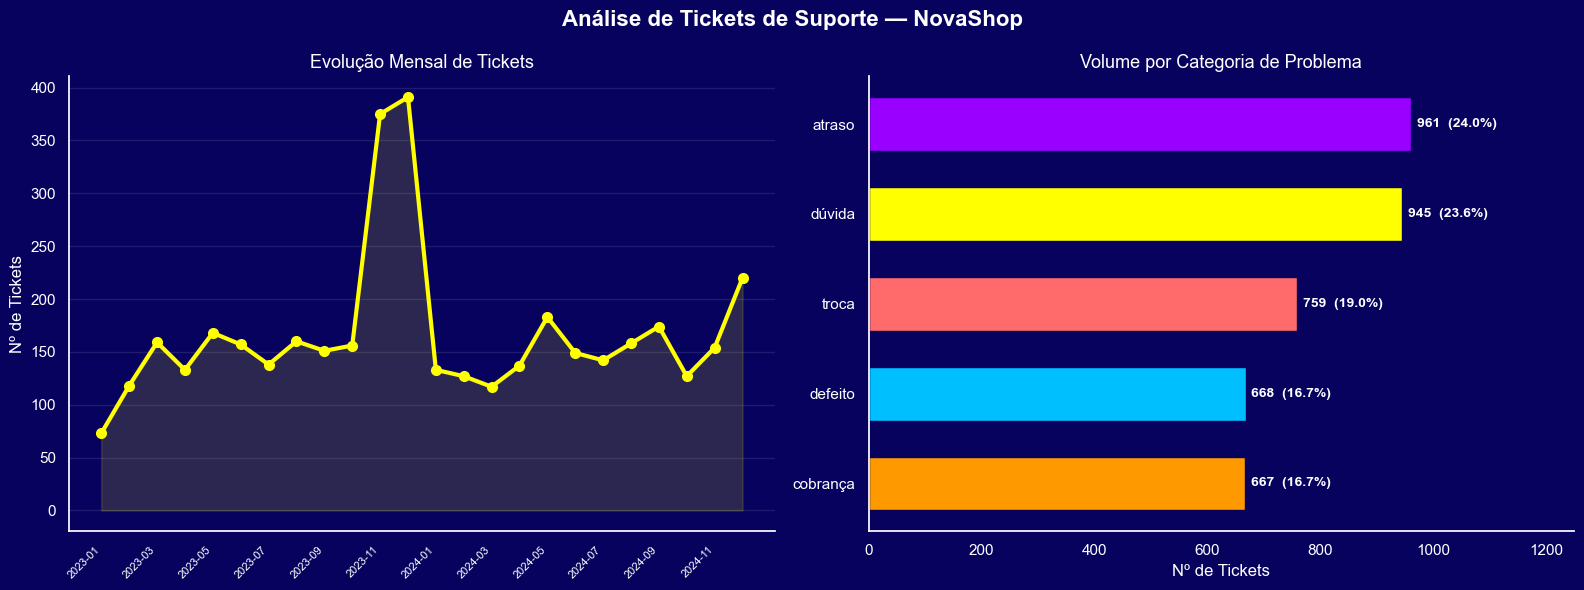

In [ ]:
# Configuração de cores e caminho
from pathlib import Path
import matplotlib.pyplot as plt

cor_fundo = "#06025e"
cor_principal = "#9900ff"
cor_alerta = "#FFFF00"
cor_texto = "#FFFFFF"
caminho_outputs = Path("outputs")
caminho_outputs.mkdir(parents=True, exist_ok=True) 

# Qual tipo de problema mais afeta o cliente?
vol_categoria = (
    df_tickets["categoria_problema"]
    .value_counts()
    .reset_index()
    .rename(columns={"count": "qtd_tickets"})
)
vol_categoria["percentual"] = (vol_categoria["qtd_tickets"] / len(df_tickets) * 100).round(2)

print("Quantidade de tickets por categoria do problema\n")
display(vol_categoria.style
    .background_gradient(subset=["qtd_tickets"], cmap="Reds")
    .format({"qtd_tickets": "{:,}", "percentual": "{:.2f}%"})
)

# Taxa de resolução por categoria 
# Cruzando status com categoria para ver onde o suporte está falhando
sla_categoria = (
    df_tickets
    .groupby("categoria_problema")
    .agg(
        total_tickets      = ("id",                  "count"),
        tickets_resolvidos = ("status",              lambda x: (x == "resolvido").sum()),
        tempo_medio_dias   = ("tempo_resolucao_dias","mean"),  
    )
    .reset_index()
)
sla_categoria["taxa_resolucao_pct"] = (
    sla_categoria["tickets_resolvidos"] / sla_categoria["total_tickets"] * 100
).round(2)
sla_categoria = sla_categoria.sort_values("taxa_resolucao_pct")  
display(
    sla_categoria.rename(columns={
        "categoria_problema": "Categoria", "total_tickets": "Total",
        "tickets_resolvidos": "Resolvidos", "taxa_resolucao_pct": "% Resolvidos",
        "tempo_medio_dias": "Tempo Médio (dias)"
    })
    .style
    .background_gradient(subset=["% Resolvidos"], cmap="RdYlGn")
    .format({"Total": "{:,}", "Resolvidos": "{:,}",
             "% Resolvidos": "{:.2f}%", "Tempo Médio (dias)": "{:.1f}"})
    .hide(axis="index")
)

#  Evolução mensal de tickets 
df_tickets["ano_mes"] = df_tickets["data_abertura"].dt.to_period("M")

evolucao_tickets = (
    df_tickets
    .groupby("ano_mes")["id"]
    .count()
    .reset_index()
    .rename(columns={"id": "qtd_tickets"})
)
evolucao_tickets["ano_mes_str"] = evolucao_tickets["ano_mes"].astype(str)

# Gráfico: evolução de tickets + categorias
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=cor_fundo)
fig.suptitle("Análise de Tickets de Suporte", fontsize=16,
             fontweight="bold", color=cor_texto)

# Gráfico 1: evolução mensal
ax1 = axes[0]
ax1.set_facecolor(cor_fundo)
ax1.plot(range(len(evolucao_tickets)), evolucao_tickets["qtd_tickets"],
         color=cor_alerta, linewidth=3, marker="o", markersize=7)
ax1.fill_between(range(len(evolucao_tickets)), evolucao_tickets["qtd_tickets"],
                 alpha=0.15, color=cor_alerta)  # Área sombreada para visibilidade
ax1.set_title("Evolução Mensal de Tickets", color=cor_texto, fontsize=13)
ax1.set_ylabel("Nº de Tickets", color=cor_texto)
ax1.set_xticks(range(0, len(evolucao_tickets), 2))
ax1.set_xticklabels(evolucao_tickets["ano_mes_str"].iloc[::2], rotation=45, ha="right",
                    color=cor_texto, fontsize=8)
ax1.tick_params(colors=cor_texto)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(cor_texto)
ax1.spines["bottom"].set_color(cor_texto)
ax1.grid(axis="y", color=cor_texto, alpha=0.1)

# Gráfico 2: volume por categoria 
ax2 = axes[1]
ax2.set_facecolor(cor_fundo)
cores_cat = [cor_principal, cor_alerta, "#FF6B6B", "#00BFFF", "#FF9900"]
bars = ax2.barh(vol_categoria["categoria_problema"], vol_categoria["qtd_tickets"],
                color=cores_cat[:len(vol_categoria)], edgecolor=cor_fundo, height=0.6)
ax2.set_title("Volume por Categoria de Problema", color=cor_texto, fontsize=13)
ax2.set_xlabel("Nº de Tickets", color=cor_texto)
ax2.invert_yaxis()  
ax2.tick_params(colors=cor_texto)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color(cor_texto)
ax2.spines["bottom"].set_color(cor_texto)

# Rótulos com valor e percentual em cada barra
for bar, (_, row) in zip(bars, vol_categoria.iterrows()):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
             f"{row['qtd_tickets']:,}  ({row['percentual']:.1f}%)",
             va="center", color=cor_texto, fontsize=10, fontweight="bold")
ax2.set_xlim(0, vol_categoria["qtd_tickets"].max() * 1.3)

plt.tight_layout()
plt.savefig(
    caminho / "evolucao_mensalTickets_categoriaProblemas.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()

Isso revela que a maioria dos tickets de suporte são decorrentes de atraso ou dúvida. Dessa forma, é crucial analisar se a maior parte dos tickets estão vindo do quarto trimestre do ano (maior volume de pedidos). 

TAXA DE CANCELAMENTO E DEVOLUÇÃO POR SEGMENTO



Segmento,Total Pedidos,Cancelados,Devolvidos,% Cancelado,% Devolvido
B2B,"3,014",523,233,17.35%,7.73%
B2C,"11,986",2014,900,16.80%,7.51%


NameError: name 'cor_alerta' is not defined

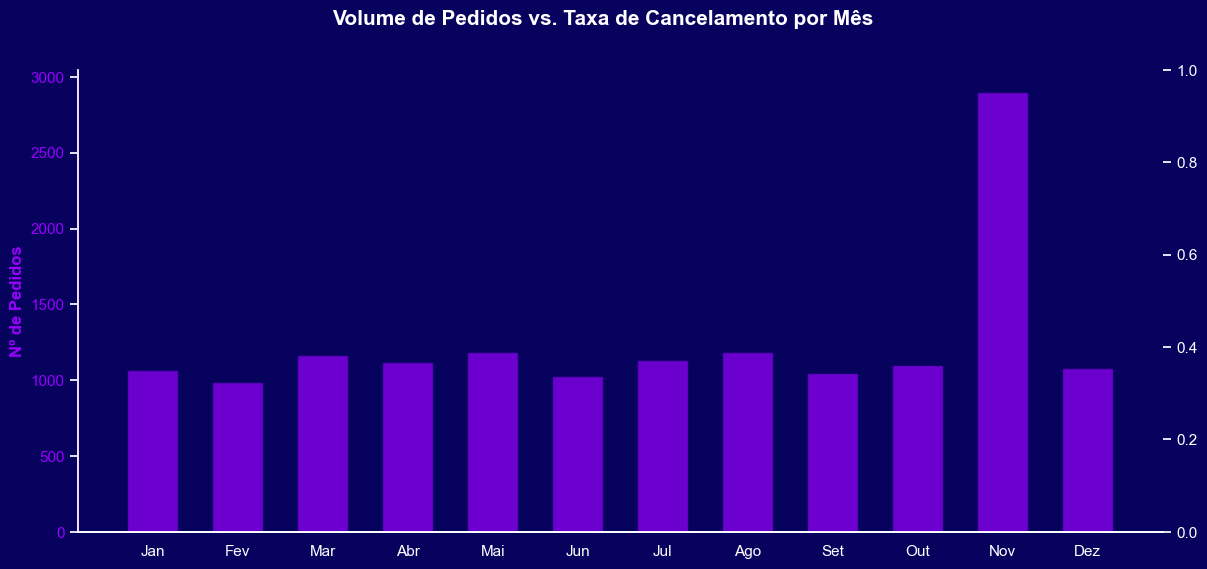

In [8]:
# Cancelamento por segmento e mês
# Há relação entre o número de tickets e os meses com maiores vendas?

# Cancelamento por segmento (B2C vs B2B)
# Na terceira pergunta foi possível verificar que B2B tem ticket maior, mas será que tem maior taxa de cancelamento?
cancel_segmento = (
    df_pedidos
    # Selecionamos apenas a coluna 'segmento' do df_clientes para evitar IDs duplicados
    .merge(df_clientes[["id", "segmento"]], left_on="cliente_id", right_on="id")
    .groupby("segmento")
    .agg(
        total           = ("id_x",   "count"), 
        cancelados      = ("status", lambda x: (x == "cancelado").sum()),
        devolvidos      = ("status", lambda x: (x == "devolvido").sum()),
    )
    .reset_index()
)

# Calcula taxas percentuais
cancel_segmento["taxa_cancel"] = (cancel_segmento["cancelados"] / cancel_segmento["total"] * 100).round(2)
cancel_segmento["taxa_devolv"] = (cancel_segmento["devolvidos"] / cancel_segmento["total"] * 100).round(2)

print("TAXA DE CANCELAMENTO E DEVOLUÇÃO POR SEGMENTO\n")
display(cancel_segmento.rename(columns={
    "segmento": "Segmento", "total": "Total Pedidos",
    "cancelados": "Cancelados", "devolvidos": "Devolvidos",
    "taxa_cancel": "% Cancelado", "taxa_devolv": "% Devolvido"
}).style.format({"% Cancelado": "{:.2f}%", "% Devolvido": "{:.2f}%",
                 "Total Pedidos": "{:,}"}).hide(axis="index"))

# Cancelamento por mês (pico de novembro piora atendimento?) 
cancel_mensal = (
    df_pedidos
    .assign(mes=df_pedidos["data_pedido"].dt.month)    
    .groupby("mes")
    .agg(
        total      = ("id",     "count"),
        cancelados = ("status", lambda x: (x == "cancelado").sum()),
    )
    .reset_index()
)
cancel_mensal["taxa_cancelamento"] = (cancel_mensal["cancelados"] / cancel_mensal["total"] * 100).round(2)
cancel_mensal["mes_nome"] = cancel_mensal["mes"].map(meses_pt)  

fig, ax1 = plt.subplots(figsize=(14, 6), facecolor=cor_fundo)
ax1.set_facecolor(cor_fundo)
fig.suptitle("Volume de Pedidos vs. Taxa de Cancelamento por Mês",
             fontsize=15, fontweight="bold", color=cor_texto)

bars = ax1.bar(cancel_mensal["mes_nome"], cancel_mensal["total"],
               color=cor_principal, alpha=0.7, edgecolor=cor_fundo, width=0.6)
ax1.set_ylabel("Nº de Pedidos", color=cor_principal, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=cor_principal)
ax1.tick_params(axis="x", colors=cor_texto)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(cor_principal)
ax1.spines["bottom"].set_color(cor_texto)

ax2 = ax1.twinx()
ax2.plot(cancel_mensal["mes_nome"], cancel_mensal["taxa_cancelamento"],
         color=cor_alerta, linewidth=3, marker="o", markersize=8, zorder=5)
ax2.set_ylabel("Taxa de Cancelamento (%)", color=cor_alerta, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=cor_alerta)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_color(cor_principal)
ax2.spines["right"].set_color(cor_alerta)
ax2.spines["bottom"].set_color(cor_texto)

plt.tight_layout()
plt.savefig(
    caminho / "volumePedidos_taxaCancelamento.png", 
    dpi=150,                         
    bbox_inches="tight",             
    facecolor=cor_fundo              
)
plt.show()


## CONCLUSÃO DO CASE

- O canal paid_search tem 30.74% de cancelamento, quase 3× acima dos outros canais e isso é observado em todos os oito trimestres analisados. Isso evidencia que não é um problema sazonal, mas sim estrutural. 
- No quarto trimestre de 2023 a empresa teve um pico de ticktes, o que decorreu do aumento do volume de pedidos (3.429 pedidos). 
- A possível razão para esse aumento de tickets de suporte é que as campanhas de paid search estão atraindo clientes com expectativas diferentes dos produtos oferecidos (seja por prazo, preço  ou qualidade do produto). Quando o cliente recebe a confirmação do pedido, acaba cancelando pois o marketing não está tendo uma boa comunicação com os clientes. 
- Dessa forma, é irremediável revisar os anúncios de paid search para identificar onde o problema se encontra: prazos fora da realidade, descontos prometidos ou especificação dos produtos. Até esse problema ser solucionado, é possível realocar o investimento para os canais de indicação e redes sociais. 
- Também é importante proteger o segmento B2B, pois este possui um ticket médio 6x maior que B2C. 